In [1]:
import numpy as np
import pandas as pd
from shapely.geometry import Polygon, LineString, Point
from shapely.ops import nearest_points
import matplotlib.pyplot as plt
import os
import tqdm  # For progress bars
from shapely import affinity

# --- Simulator primitives ---
from data_simulations import (
    TissueCellTypes,
    CellTypesProperties,
    HybISS_Setup,
    FOV,
    FOVDistribution,
    TissueSlice,
    ProbabilityNodeFieldRule,
    SingleTypeRule,
    MixOfNCellTypesRule,
    FrameWideElement,
    VacuolatedStructure,
    HistologicalElement,
    IdentityTransfer,
    RegionSpec,
)

# =========================================================================
#  GLOBAL PARAMETERS
# =========================================================================
GLOBAL_WIDTH = 800
GLOBAL_HEIGHT = 800
FRAME_SIZE = max(GLOBAL_HEIGHT, GLOBAL_WIDTH)

# --- White matter settings (pre-warp space) ---
WM_CENTER = (320, 560)     # moved up-right
WM_RADIUS = 110            # larger core
N_WM_TYPES = 2

# Shape/pose of WM ellipse BEFORE the global warp
WM_ELLIPSE_AX = 1.80       # x-stretch of the WM ellipse (>=1 widens to the right)
WM_ELLIPSE_AY = 0.90       # y-stretch (<=1 flattens vertically)
WM_PRE_ROTATE_DEG = 20     # rotate the ellipse counterclockwise before the global warp


# --- Warp to “lean” layers toward the upper-right (like your reference) ---
ROTATE_DEG = -18     # clockwise tilt
SKEW_Y_DEG = 26      # skew along Y; + pushes the top to the right
SCALE_X    = 1.18    # widen
SCALE_Y    = 0.86    # flatten
SHIFT_X    = 50      # final nudge right
SHIFT_Y    = 0       # final nudge vertical

# The "origin" point for the (legacy) arc generator (only used if you plot arcs)
LAYER_ORIGIN_X = -200
LAYER_ORIGIN_Y = -200

# Define the layers (names + number of types per layer).
# (The radius entries from your earlier code are not used now; layers come from WM buffers.)
CORTEX_LAYERS_INFO = [
    ("Layer_1", 300, 1),
    ("Layer_2", 400, 1),
    ("Layer_3", 500, 1),
    ("Layer_4", 600, 1),
    ("Layer_5", 700, 1),
    ("Layer_6", 800, 1),
]
LAYER_NAMES = [n for n, _, _ in CORTEX_LAYERS_INFO]
LAYER_NUM_TYPES = [k for _, _, k in CORTEX_LAYERS_INFO]

# Layer thicknesses (pixels in *pre-warp* space, inner→outer), tuned to reach frame edges after warping
LAYER_THICKNESSES = [80, 90, 105, 120, 140, 165]

# Optional waviness helper (kept from your earlier version; not used for WM shells)
LAYER_WAVINESS_AMPLITUDE = 20
LAYER_N_POINTS = 100

# =========================================================================
#  GEOMETRY HELPERS (white-matter core + stretched shells)
# =========================================================================

def _warp(poly: Polygon) -> Polygon:
    """Rotate → skewY → anisotropic scale → translate, then clip to frame."""
    p = affinity.rotate(poly, ROTATE_DEG, origin=(0, 0), use_radians=False)
    p = affinity.skew(p, xs=0.0, ys=SKEW_Y_DEG, origin=(0, GLOBAL_HEIGHT), use_radians=False)
    p = affinity.scale(p, xfact=SCALE_X, yfact=SCALE_Y, origin=(0, GLOBAL_HEIGHT))
    p = affinity.translate(p, xoff=SHIFT_X, yoff=SHIFT_Y)
    frame_poly = Polygon([(0, 0), (GLOBAL_WIDTH, 0), (GLOBAL_WIDTH, GLOBAL_HEIGHT), (0, GLOBAL_HEIGHT)])
    return p.intersection(frame_poly)

def build_wm_and_layers(wm_center, wm_radius, layer_thicknesses):
    """
    Build a white-matter (core) polygon and six outward shells (L1..L6) around it.
    Geometry is constructed in pre-warp space and then warped once.
    Returns:
        wm_poly, layers_polys  where layers_polys[0] is L1 (innermost cortical),
        layers_polys[5] is L6 (outermost).
    """
    # 1) WM core in pre-warp space (slightly elliptical)
    # Base circle
    wm_raw = Point(wm_center).buffer(wm_radius, resolution=128)
    # Turn into an oriented ellipse BEFORE the global warp
    wm_raw = affinity.scale(wm_raw, xfact=WM_ELLIPSE_AX, yfact=WM_ELLIPSE_AY, origin=wm_center)
    wm_raw = affinity.rotate(wm_raw, WM_PRE_ROTATE_DEG, origin=wm_center, use_radians=False)


    # 2) Outward envelopes by cumulative buffers
    cum = 0
    envelopes_raw = []
    for th in layer_thicknesses:
        cum += th
        envelopes_raw.append(wm_raw.buffer(cum))

    # 3) Warp to get the “stretched” look
    wm_poly = _warp(wm_raw)
    envelopes = [_warp(e) for e in envelopes_raw]

    # 4) Differencing yields disjoint bands
    layers = []
    prev = wm_poly
    for env in envelopes:
        band = env.difference(prev)
        layers.append(band)
        prev = env

    return wm_poly, layers  # L1..L6

# =========================================================================
#  TYPE ACCOUNTING (WM first, then L1..L6)
# =========================================================================
current_id = 0
wm_type_ids = list(range(current_id, current_id + N_WM_TYPES))
current_id += N_WM_TYPES

layer_cell_type_id_ranges = []
for name, n in zip(LAYER_NAMES, LAYER_NUM_TYPES):
    ids = list(range(current_id, current_id + n))
    layer_cell_type_id_ranges.append((name, ids))
    current_id += n

# Total number of cell types (WM + all layers)
N_TOTAL_CELL_TYPES = current_id

# =========================================================================
#  FOV DISTRIBUTIONS (one for WM, one per layer)
# =========================================================================
# WM region rule & distribution
wm_rule = [MixOfNCellTypesRule(
    N_TOTAL_CELL_TYPES,
    list_N=wm_type_ids,
    proportions=[1.0 / len(wm_type_ids)] * len(wm_type_ids),
)]
WM_BG = lambda r=wm_rule: FrameWideElement(
    frame_size=FRAME_SIZE,
    tipical_cell_spacing=10,  # dense WM
    rules=r,
)
fovd_wm = FOVDistribution(
    frame_size=FRAME_SIZE,
    background_element=WM_BG,
    other_elements=[],
    elements_frequency=[],
    attempts_at_elements=[],
)

# Cortical layer distributions
layer_fov_distributions = []
for idx, (name, _, num_types) in enumerate(CORTEX_LAYERS_INFO):
    ids = dict(layer_cell_type_id_ranges)[name]
    layer_bg_rule = [MixOfNCellTypesRule(
        N_TOTAL_CELL_TYPES,
        list_N=ids,
        proportions=[1.0 / len(ids)] * len(ids),
    )]
    # capture rule by value
    LayerBGPrototype = (lambda r=layer_bg_rule: FrameWideElement(
        frame_size=FRAME_SIZE,
        tipical_cell_spacing=10,  # you can vary by layer if you want
        rules=r,
    ))
    layer_fovd = FOVDistribution(
        frame_size=FRAME_SIZE,
        background_element=LayerBGPrototype,
        other_elements=[],
        elements_frequency=[],
        attempts_at_elements=[],
    )
    layer_fov_distributions.append((name, layer_fovd))

# =========================================================================
#  MAIN
# =========================================================================
print("Initializing tissue and experiment...")
tissue = TissueCellTypes()
tissue.generate_types_and_markers(
    n_genes=50,
    n_cell_types=N_TOTAL_CELL_TYPES,   # <-- use the computed total
    expected_level=50.0,
    expected_std_level=5.0,
    concentration=0.9,
)

# Output dirs
os.makedirs("output_cortex/data", exist_ok=True)
os.makedirs("output_cortex/parameters", exist_ok=True)
os.makedirs("output_cortex/ground_truths", exist_ok=True)

tissue.make_pandas_df().to_csv("output_cortex/parameters/cell_types.csv", index=False)

# Visual/biophysical cell props
cell_props = CellTypesProperties(
    n_cell_types=N_TOTAL_CELL_TYPES,
    sizes=12,
    size_variation=0.2,
    anisotropy=1.5,
    anisotropy_variation=0.3,
    relative_rna_concentration=1.0,
    rna_concentration_variation=0.05,
)

# HybISS setup
hybISS = HybISS_Setup(
    tissue,
    genes_sensitivities=1.0,
    genes_sensitivities_variation=0.1,
    transfer_function=IdentityTransfer(),
)
print("Tissue and experiment initialized.")

# --- Build white matter + stretched cortical shells ---
print("Generating WM core and stretched cortical layers...")
wm_poly, layers_polys = build_wm_and_layers(
    WM_CENTER, WM_RADIUS, LAYER_THICKNESSES
)
cortex_polygons = list(zip(LAYER_NAMES, layers_polys))  # [(L1, poly1), ..., (L6, poly6)]

# --- Assemble regions with correct priorities ---
# Highest priority: WM; then L1..L6 descending (inner overrides outer)
all_regions = []

all_regions.append(RegionSpec(
    name="WhiteMatter",
    polygon=wm_poly,
    fovdist=fovd_wm,
    priority=100,
    blend_band=16.0,
))

for i, (layer_name, polygon) in enumerate(cortex_polygons):  # L1..L6
    fovd = next(f for name, f in layer_fov_distributions if name == layer_name)
    all_regions.append(RegionSpec(
        name=layer_name,
        polygon=polygon,
        fovdist=fovd,
        priority=90 - i,      # L1: 90 ... L6: 85 (any decreasing scheme is fine)
        blend_band=14.0,
    ))

print(f"Defined {len(all_regions)} regions (1 WM + 6 layers).")

# --- Compose tissue slice ---
print("Creating tissue slice and generating global tissue...")
tissue_slice = TissueSlice(frame_size=FRAME_SIZE, regions=all_regions)
tissue_slice.generate_global()
tissue_slice.sample_labels()

print(f"Generated {len(tissue_slice._cells_xy)} total cells.")

# --- Global export (cells + dots) ---
print("Generating global data...")
global_fov = FOV(
    cell_centroids=tissue_slice._cells_xy,
    cell_probabilities=tissue_slice._probs,
)
global_fov.class_instance_one_hot = tissue_slice._class_onehot

cell_props.apply(global_fov)
hybISS.observe_dots(global_fov)

global_cells_df = global_fov.make_pandas_df()
global_dots_df = hybISS.make_pandas_df()

print(f"Saving global data: {len(global_cells_df)} cells, {len(global_dots_df)} dots")
global_cells_df.to_csv("output_cortex/ground_truths/global_ground_truth_cells.csv", index=False)
global_dots_df.to_csv("output_cortex/ground_truths/global_ground_truth_dots.csv", index=False)

global_cells_df[["X", "Y"]].to_csv("output_cortex/data/global_cell_centroids.csv", index=False)
global_dots_df[["x", "y", "gene"]].to_csv("output_cortex/data/global_dots.csv", index=False)
print("Global data saved.")

# --- Tile into NON-OVERLAPPING FOVs ---
FOV_SIZE = 100
OVERLAP = 0.0
print(f"Tiling into {FOV_SIZE}px NON-overlapping FOVs...")
fov_tiles = tissue_slice.tile_into_fovs(fov_size=FOV_SIZE, overlap_frac=OVERLAP)
print(f"Created {len(fov_tiles)} non-overlapping FOV tiles.")

print("Processing and saving individual non-overlapping tiles...")
for idx_tile, tile in tqdm.tqdm(enumerate(fov_tiles)):
    tile_indices = tile["idx"]
    if len(tile_indices) == 0:
        continue

    fov_xy = tissue_slice._cells_xy[tile_indices]
    fov_probs = tissue_slice._probs[tile_indices]
    fov_onehot = tissue_slice._class_onehot[tile_indices]

    fov = FOV(cell_centroids=fov_xy, cell_probabilities=fov_probs)
    fov.class_instance_one_hot = fov_onehot

    cell_props.apply(fov)
    hybISS.observe_dots(fov)

    dots_df = hybISS.make_pandas_df()
    cells_df = fov.make_pandas_df()

    dots_df[["x", "y", "gene"]].to_csv(f"output_cortex/data/dots_FOV{idx_tile:03d}.csv", index=False)
    dots_df.to_csv(f"output_cortex/ground_truths/dots_FOV{idx_tile:03d}.csv", index=False)

    cells_df[["X", "Y"]].copy().to_csv(f"output_cortex/data/cell_centroids_FOV{idx_tile:03d}.csv", index=False)
    cells_df.to_csv(f"output_cortex/ground_truths/ground_truth_FOV{idx_tile:03d}.csv", index=False)

print("Done processing all tiles.")

Initializing tissue and experiment...
Tissue and experiment initialized.
Generating WM core and stretched cortical layers...
Defined 7 regions (1 WM + 6 layers).
Creating tissue slice and generating global tissue...
Generated 7255 total cells.
Generating global data...
Saving global data: 7255 cells, 365335 dots
Global data saved.
Tiling into 100px NON-overlapping FOVs...
Created 64 non-overlapping FOV tiles.
Processing and saving individual non-overlapping tiles...


64it [00:01, 49.58it/s]

Done processing all tiles.


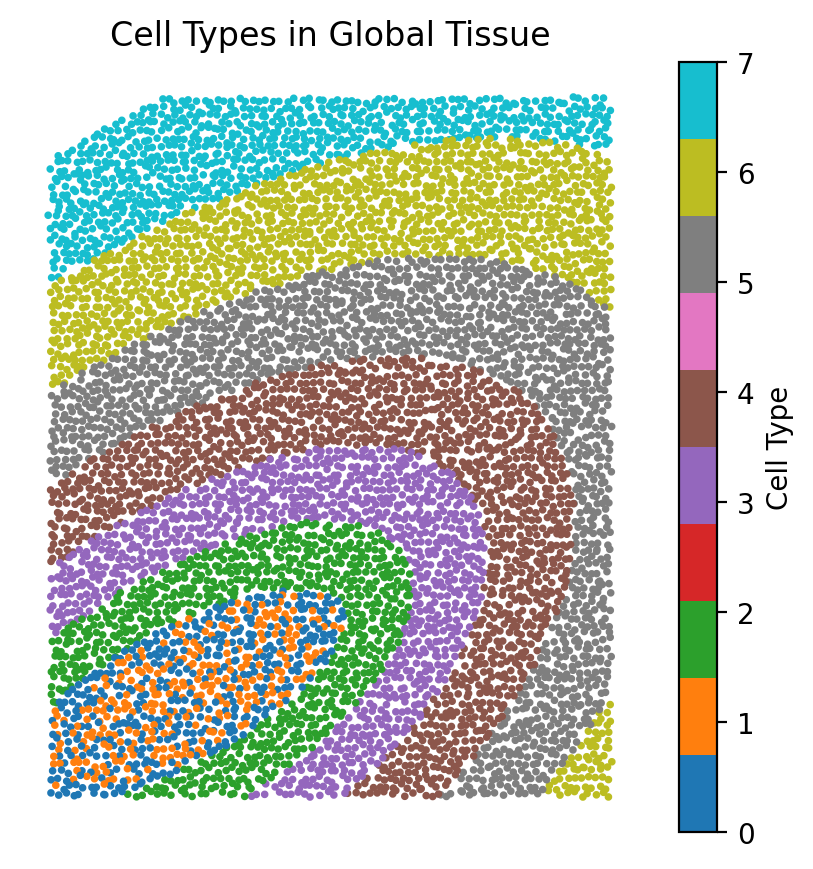

In [2]:
cell_df_global = pd.read_csv('output_cortex/ground_truths/global_ground_truth_cells.csv')
dots_df_global = pd.read_csv('output_cortex/ground_truths/global_ground_truth_dots.csv')

plt.figure(figsize=(5, 5), dpi=200)
plt.scatter(cell_df_global['X'], cell_df_global['Y'], c=cell_df_global['Class ID'], cmap='tab10', s=3)
plt.colorbar(label='Cell Type')
plt.title('Cell Types in Global Tissue')
plt.axis('off')
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.show()